## Figure 3A. Taxonomic annotation of UHVDB

In [1]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [45]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('seq_name') == pl.col('seqhash_rep')) & (pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('seq_name')
)

In [46]:
## load uhvdb taxonomy outputs
df_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/taxonomy/new_genomovars_ictv_taxonomy.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    df_lst.append(df)

combined_df = pl.concat(df_lst)

In [47]:
### filter to just final uhvdb genomovar reps
uhvdb_taxa_df = combined_df.filter(pl.col('uhvdb_id').is_in(set(combined['genomovar_rep']))).sort('normscore', descending=True).unique('uhvdb_id', maintain_order=True)
print("total UHVDB genomovars:", uhvdb_taxa_df.shape[0])

total UHVDB genomovars: 508178


In [48]:
### Count number of queries with any hits to ICTV
print("Number of UHVDB genomes with a hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col('normscore') > 0).height
)

Number of UHVDB genomes with a hit to ICTV: 299203


In [49]:
### Count number of queries with family, subfamily, genus, subgenus, species level hits
print("% of UHVDB genomes with family hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col('normscore') >= 5.5).height / uhvdb_taxa_df.height * 100
)

print("% of UHVDB genomes with subfamily hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col('normscore') >= 32).height / uhvdb_taxa_df.height * 100
)

print("% of UHVDB genomes with genus hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col('normscore') >= 65).height / uhvdb_taxa_df.height * 100
)

print("% of UHVDB genomes with subgenus hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col('normscore') >= 80).height / uhvdb_taxa_df.height * 100
)

print("% of UHVDB genomes with species hit to ICTV:",
    uhvdb_taxa_df.filter(pl.col('normscore') >= 95).height / uhvdb_taxa_df.height * 100
)

% of UHVDB genomes with family hit to ICTV: 58.877598006997545
% of UHVDB genomes with subfamily hit to ICTV: 10.648040647174808
% of UHVDB genomes with genus hit to ICTV: 5.633262360826325
% of UHVDB genomes with subgenus hit to ICTV: 3.954323091515178
% of UHVDB genomes with species hit to ICTV: 0.4777853429310202


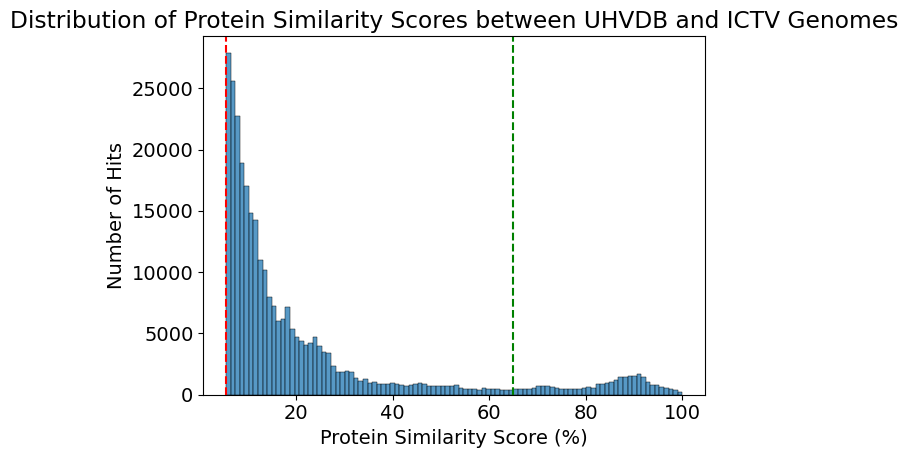

In [50]:
# create histogram of protein similarity scores
sns.histplot(data=uhvdb_taxa_df.group_by('uhvdb_id').agg([pl.col('normscore').max().alias('max_similarity')]), x='max_similarity', bins=100)
plt.xlabel('Protein Similarity Score (%)')
plt.ylabel('Number of Hits')
# plt.yscale('log')
plt.title('Distribution of Protein Similarity Scores between UHVDB and ICTV Genomes')
plt.axvline(x=5.5, color='red', linestyle='--', label='Family Level Threshold (5.5%)')
plt.axvline(x=65, color='green', linestyle='--', label='Genus Level Threshold (65%)')
# plt.legend()
plt.tight_layout()
plt.show()

In [51]:
uhvdb_taxa_df.group_by('Class').len().sort('len', descending=True).head(15)

Class,len
str,u32
"""Caudoviricetes""",471039
"""Malgrandaviricetes""",21157
"""Faserviricetes""",9446
"""Papovaviricetes""",2447
"""Cardeaviricetes""",1917
…,…
"""Repensiviricetes""",119
"""Tectiliviricetes""",98
"""Pokkesviricetes""",79


In [71]:
uhvdb_taxa_df.filter(~pl.col('taxonomy').str.contains('Ribo')).group_by('Class').len().sort('len', descending=True).write_csv('class_counts.tsv', separator='\t')

In [53]:
### Assign ICTV hits without a family-level hit to "Unclassified" category
uhvdb_taxa_df = uhvdb_taxa_df.with_columns(
    pl.when((pl.col('normscore') >= 5.5) & (pl.col('Family').is_not_null()))
        .then(pl.col('Family'))
        .when((pl.col('normscore') >= 5.5) & (pl.col('Family').is_null()))
        .then(pl.lit('Unclassified') + " " + pl.col('Class'))
        .alias('Family')
)

In [59]:
uhvdb_taxa_df.group_by('Family').len().sort('len', descending=True).head(10)

Family,len
str,u32
null,208975
"""Unclassified Caudoviricetes""",201614
"""Peduoviridae""",12133
"""Salasmaviridae""",7754
"""Microviridae""",7556
"""Aliceevansviridae""",7064
"""Konodaiviridae""",6393
"""Suoliviridae""",5709
"""Toyamaviridae""",5186


In [60]:
201614 / 299203

0.6738368265024081

/tmp/ipykernel_63337/2323783462.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([
/tmp/ipykernel_63337/2323783462.py:24: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index='body_site', columns='Family_classified', values='len', aggregate_function='sum')


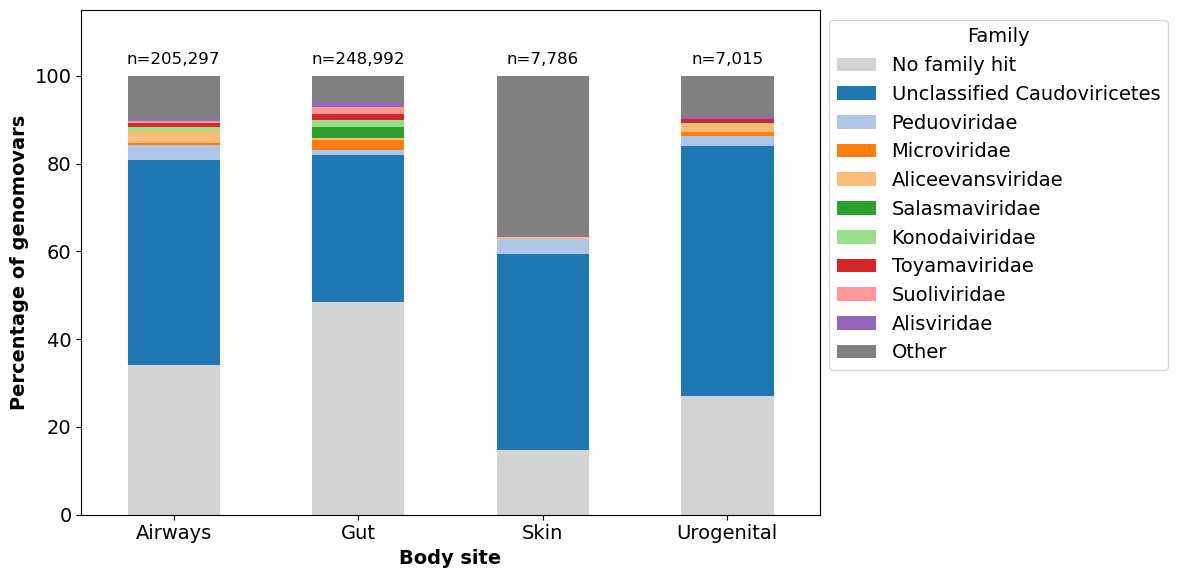

In [58]:
# Get top 10 families overall
top_families = uhvdb_taxa_df.group_by('Family').len().sort('len', descending=True).head(10)['Family']

# Classify families as top 10 or "Other"
family_hits_classified = (
    uhvdb_taxa_df
        .join(combined[['genomovar_rep', 'body_site']], left_on='uhvdb_id', right_on='genomovar_rep', how='left')
        .unique('uhvdb_id')
        .filter(pl.col('body_site') != 'Other')
        .with_columns([
            pl.when(pl.col('Family').is_in(top_families))
                .then(pl.col('Family'))
                .when(pl.col('Family').is_null())
                .then(pl.lit('No family hit'))
                .otherwise(pl.lit('Other'))
                .alias('Family_classified')
        ])
)

family_by_site = (
    family_hits_classified
        .group_by(['body_site', 'Family_classified'])
        .len()
        .pivot(index='body_site', columns='Family_classified', values='len', aggregate_function='sum')
        .fill_null(0)
)

# Convert to pandas for easier manipulation
family_by_site_pd = family_by_site.to_pandas().set_index('body_site')
family_by_site_pd = family_by_site_pd.sort_index()  # Alphabetical x-axis order

# Calculate total counts per body site
totals = family_by_site_pd.sum(axis=1)

# Calculate proportions (normalize to 100%)
family_proportions = family_by_site_pd.div(totals, axis=0) * 100

# Order families by total count across all body sites, with Other at the bottom
family_total_counts = family_by_site_pd.sum(axis=0)
if 'Other' in family_total_counts.index:
    ordered_cols = family_total_counts.drop('Other').sort_values(ascending=False).index.tolist() + ['Other']
else:
    ordered_cols = family_total_counts.sort_values(ascending=False).index.tolist()

family_proportions = family_proportions[ordered_cols]

# Create custom color palette - use default colors for families, light grey for No family hit, grey for Other
plt.rcParams.update({'font.size': 14})
special_labels = {'No family hit', 'Other'}
n_families = len([c for c in family_proportions.columns if c not in special_labels])
base_colors = plt.cm.tab20.colors[:n_families]
base_color_iter = iter(base_colors)
colors = []
for col in family_proportions.columns:
    if col == 'No family hit':
        colors.append('#D3D3D3')  # Light grey
    elif col == 'Other':
        colors.append('#808080')  # Grey
    else:
        colors.append(next(base_color_iter))

# Create stacked bar chart with proportions
ax = family_proportions.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
# make x-axis tick labels horizontal
plt.xticks(rotation=0)
plt.xlabel('Body site', fontdict={'fontweight': 'bold'})
plt.ylabel('Percentage of genomovars', fontdict={'fontweight': 'bold'})
plt.legend(title='Family', bbox_to_anchor=(1.0, 1), loc='upper left')

# Add total counts above each bar
for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, 102, f'n={int(total):,}', ha='center', va='bottom', fontsize=12)

plt.ylim(0, 115)  # Make room for the count labels
plt.tight_layout()
plt.show()

/tmp/ipykernel_63337/2043030762.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([
/tmp/ipykernel_63337/2043030762.py:24: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index='body_site', columns='Class_classified', values='len', aggregate_function='sum')


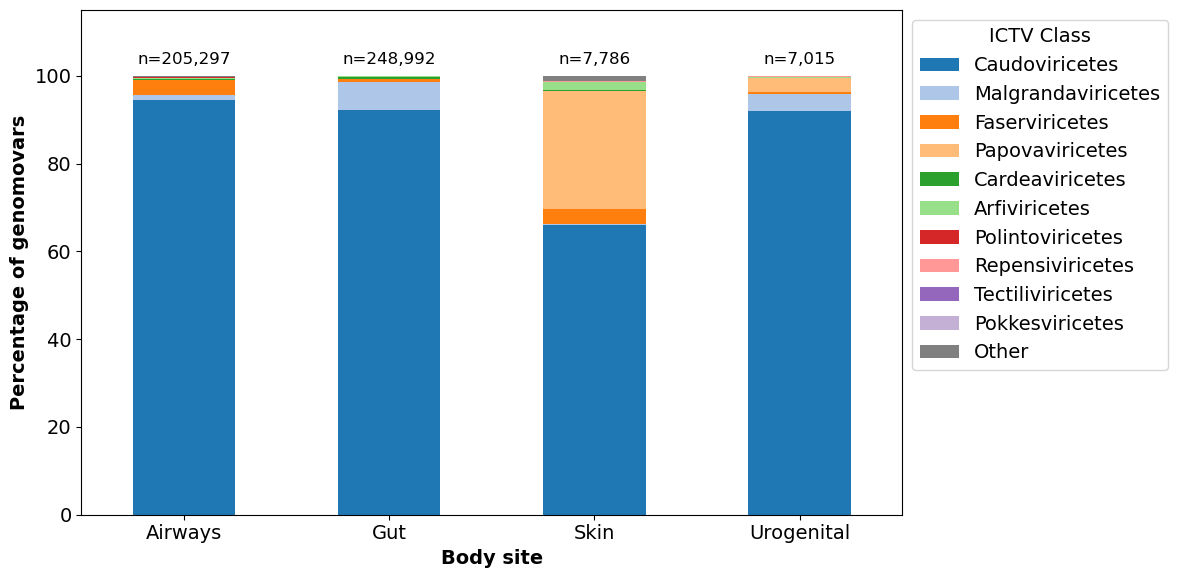

In [72]:
# Get top 10 families overall
top_families = uhvdb_taxa_df.filter(~pl.col('taxonomy').str.contains('Ribo')).group_by('Class').len().sort('len', descending=True).head(10)['Class']

# Classify families as top 10 or "Other"
family_hits_classified = (
    uhvdb_taxa_df
        .join(combined[['genomovar_rep', 'body_site']], left_on='uhvdb_id', right_on='genomovar_rep', how='left')
        .unique('uhvdb_id')
        .filter(pl.col('body_site') != 'Other')
        .with_columns([
            pl.when(pl.col('Class').is_in(top_families))
                .then(pl.col('Class'))
                .when(pl.col('Class').is_null())
                .then(pl.lit('No family hit'))
                .otherwise(pl.lit('Other'))
                .alias('Class_classified')
        ])
)

family_by_site = (
    family_hits_classified
        .group_by(['body_site', 'Class_classified'])
        .len()
        .pivot(index='body_site', columns='Class_classified', values='len', aggregate_function='sum')
        .fill_null(0)
)

# Convert to pandas for easier manipulation
family_by_site_pd = family_by_site.to_pandas().set_index('body_site')
family_by_site_pd = family_by_site_pd.sort_index()  # Alphabetical x-axis order

# Calculate total counts per body site
totals = family_by_site_pd.sum(axis=1)

# Calculate proportions (normalize to 100%)
family_proportions = family_by_site_pd.div(totals, axis=0) * 100

# Order families by total count across all body sites, with Other at the bottom
family_total_counts = family_by_site_pd.sum(axis=0)
if 'Other' in family_total_counts.index:
    ordered_cols = family_total_counts.drop('Other').sort_values(ascending=False).index.tolist() + ['Other']
else:
    ordered_cols = family_total_counts.sort_values(ascending=False).index.tolist()

family_proportions = family_proportions[ordered_cols]

# Create custom color palette - use default colors for families, light grey for No class hit, grey for Other
plt.rcParams.update({'font.size': 14})
special_labels = {'No class hit', 'Other'}
n_families = len([c for c in family_proportions.columns if c not in special_labels])
base_colors = plt.cm.tab20.colors[:n_families]
base_color_iter = iter(base_colors)
colors = []
for col in family_proportions.columns:
    if col == 'No class hit':
        colors.append('#D3D3D3')  # Light grey
    elif col == 'Other':
        colors.append('#808080')  # Grey
    else:
        colors.append(next(base_color_iter))

# Create stacked bar chart with proportions
ax = family_proportions.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
# make x-axis tick labels horizontal
plt.xticks(rotation=0)
plt.xlabel('Body site', fontdict={'fontweight': 'bold'})
plt.ylabel('Percentage of genomovars', fontdict={'fontweight': 'bold'})
plt.legend(title='ICTV Class', bbox_to_anchor=(1.0, 1), loc='upper left')

# Add total counts above each bar
for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, 102, f'n={int(total):,}', ha='center', va='bottom', fontsize=12)

plt.ylim(0, 115)  # Make room for the count labels
plt.tight_layout()
plt.show()

In [70]:
family_proportions

,Caudoviricetes,Malgrandaviricetes,Faserviricetes,Papovaviricetes,Cardeaviricetes,Arfiviricetes,Polintoviricetes,Repensiviricetes,Tectiliviricetes,Pokkesviricetes,Other
body_site,,,,,,,,,,,
Airways,94.581022,1.034112,3.383878,0.025329,0.334637,0.078423,0.18802,0.018510,0.018023,0.033610,0.304437
Gut,92.219830,6.456031,0.628936,0.018073,0.477927,0.079922,0.00000,0.028113,0.022491,0.000000,0.068677
Skin,65.951708,0.256871,3.416388,26.945800,0.089905,2.016440,0.00000,0.077061,0.000000,0.128436,1.117390
Urogenital,91.974341,3.863150,0.384890,3.221668,0.114041,0.285103,0.00000,0.014255,0.000000,0.000000,0.142552
